# Proyecto de telecomunicaciones

### Empezamos a cargar las librerías a usar, y losDatasets

In [1]:
# Cargamos las liberrías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy import stats

In [2]:
# cargamos el dataset

clients = pd.read_csv('telecom_clients.csv')

calls = pd.read_csv('telecom_dataset_new.csv')

## Exploración de los datos

In [3]:
# Revisamos las primeras filas del dataset, y su información general

print(clients.head(),
      clients.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB
   user_id tariff_plan  date_start
0   166713           A  2019-08-15
1   166901           A  2019-08-23
2   168527           A  2019-10-29
3   167097           A  2019-09-01
4   168193           A  2019-10-16 None


In [4]:
print(calls.head(),
      calls.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     

In [5]:
# Veremos si hay valores nulos en el dataset
calls.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [6]:
# Veremos si hay valores nulos en el dataset
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

In [7]:
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [8]:
calls['operator_id'].nunique()
calls['user_id'].nunique()

307

In [9]:
calls.groupby('direction')['calls_count'].sum()

direction
in     216863
out    669892
Name: calls_count, dtype: int64

In [10]:
calls.duplicated().sum()

np.int64(4900)

### Primeras observaciones

- En el conjunto de datos df_new, el tipo de dato de la columna 'date' es object, deberíamos cambiarlo a tipo 'datetime'.
- En el conjnto de datos clients, el tipo de dato de la columna 'date_start' es object, lo cambiaremos a tipo 'datetime'.
- Vemos valores nulos en las columnas 'internal' y 'operator_id' del Dataset **calls**

### Limpieza de los datos

In [11]:
# convertir fechas

# convertimos la columna 'date' del Dataset df_new a datetime
calls['date'] = pd.to_datetime(calls['date'])

# convertimos la columna 'date_start' del Dataset clients a datetime
clients['date_start'] = pd.to_datetime(clients['date_start'])

In [12]:
# Eliminamos los valores nulos del dataset df_new

calls = calls.dropna(subset=['operator_id', 'internal'])

# verificamos que se hayan eliminado los valores nulos del dataset df_new
calls.isna().sum()

user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

### Cambios realizados
- Se corrigió la conversión de la columna 'date_start' del Dataset **clients** a datetime.
- Se eliminaron los valores nulos de las columnas 'internal' y 'operator_id' del Dataset **calls** porque no se puede analizar un operador si el dato es nulo.

## Operadores ineficaces

Ahora, que nuestros datos están limpios, podemos identificar qué operadores están siendo ineficaces, tomando en cuenta la cantidad de llamadas perdidas (internas y externas) y un el tiempo de espera para las llamadas entrantes. 

In [13]:
calls.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,45670.000000,45670.000000,45670.000000,45670.000000,45670.000000
mean,167302.011408,916529.298796,16.925203,1010.934399,1323.697000
std,600.836406,21258.404689,59.081220,4017.101865,4735.336635
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,68.000000
50%,167175.000000,913938.000000,4.000000,107.000000,291.000000
75%,167827.000000,937708.000000,14.000000,774.000000,1112.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [14]:
# Revisamos la cantidad de llamadas internas (entre el personal) vs llamadas externas (con clientes)
calls['internal'].value_counts()

internal
False    39861
True      5809
Name: count, dtype: int64

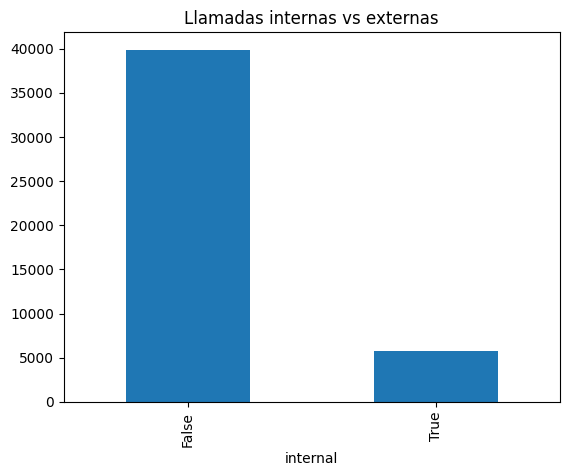

In [15]:
# Distribución de llamadas internas vs externas
calls['internal'].value_counts().plot(
    kind='bar', title='Llamadas internas vs externas')
plt.show()

In [16]:
# LLamadas entrantes vs llamadas salientes
calls['direction'].value_counts()

direction
out    31717
in     13953
Name: count, dtype: int64

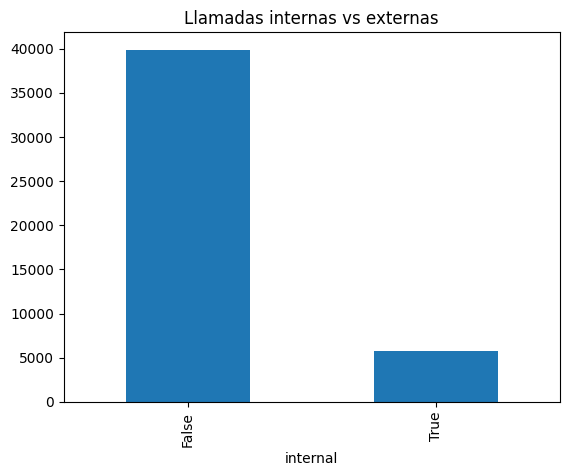

In [17]:
# Distribución de llamadas internas vs externas
calls['internal'].value_counts().plot(
    kind='bar', title='Llamadas internas vs externas')
plt.show()

### Metricas de llamadas

In [18]:
# Tiempo de espera
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

In [ ]:
# Crear wait_time
calls['wait_time'] = calls['total_call_duration'] - calls['call_duration']

# Agrupar
operator_stats = calls.groupby('operator_id').agg({
    'calls_count': 'sum',
    'is_missed_call': 'mean',
    'call_duration': 'mean',
    'wait_time': 'mean',
}).reset_index()

# Renombrar
operator_stats = operator_stats.rename(columns={
    'is_missed_call': 'missed_rate'
})

# Llamadas salientes
outgoing = calls[calls['direction'] == 'out']

outgoing_calls = outgoing.groupby(
    'operator_id')['calls_count'].sum().reset_index()
outgoing_calls = outgoing_calls.rename(
    columns={'calls_count': 'outgoing_calls'})

# Merge
operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')

# Fill NA
operator_stats['outgoing_calls'] = operator_stats['outgoing_calls'].fillna(0)

### Criterios para identificar operadores ineficaces

- Tienen muchas llamadas perdidas.
- tienen un alto tiempo de espera.
- Tienen pocas llamadas salientes.

In [20]:
operator_stats.mean()

operator_id       925517.543956
calls_count          707.851648
missed_rate            0.314488
call_duration        649.146970
wait_time            215.603594
outgoing_calls       612.951465
dtype: float64

In [21]:
operator_stats.head()

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls
0,879896.0,1131,0.390625,650.476562,110.671875,1071.0
1,879898.0,7973,0.400000,1115.504000,451.860000,7856.0
2,880020.0,54,0.318182,104.090909,15.181818,46.0
3,880022.0,219,0.434211,240.842105,57.565789,211.0
4,880026.0,2439,0.474747,856.939394,121.171717,2414.0


In [22]:
operator_stats.describe()

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000
mean,925517.543956,707.851648,0.314488,649.146970,215.603594,612.951465
std,22854.532209,3181.520411,0.231362,1197.515913,504.973933,3103.139223
min,879896.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,906393.500000,11.000000,0.125000,76.655556,23.058824,2.000000
50%,925105.000000,78.500000,0.333333,240.048325,46.259878,36.500000
75%,944211.500000,558.000000,0.461538,659.824661,155.541011,388.750000
max,973286.000000,66049.000000,1.000000,14620.545455,5907.443038,64897.000000


In [23]:
operator_stats.sort_values(by='missed_rate', ascending=False).head(15)

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls
386,914626.0,1,1.0,0.0,0.000000,1.0
381,914272.0,1,1.0,0.0,9.000000,1.0
1030,960674.0,2,1.0,0.0,0.000000,2.0
982,955068.0,2,1.0,0.0,0.000000,2.0
1011,958458.0,1,1.0,0.0,0.000000,1.0
528,924572.0,1,1.0,0.0,1.000000,1.0
247,905308.0,3,1.0,0.0,15.000000,3.0
253,905480.0,1,1.0,0.0,5.000000,1.0
569,928282.0,2,1.0,0.0,8.000000,2.0
970,954284.0,1,1.0,0.0,3.000000,1.0


In [24]:
operator_stats.sort_values(by='wait_time', ascending=False).head(15)

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls
551,925922.0,22210,0.417722,11759.924051,5907.443038,21754.0
29,885890.0,66016,0.397112,13238.747292,5727.133574,64653.0
583,929428.0,24572,0.500000,4194.285714,5325.342857,24572.0
28,885876.0,66049,0.423197,14620.545455,4816.241379,64897.0
317,908640.0,16699,0.461538,6164.538462,3456.461538,16699.0
582,929426.0,12041,0.514706,4114.573529,3316.558824,12041.0
843,945278.0,4314,0.520833,4968.687500,2858.479167,4314.0
448,919364.0,5096,0.534884,2286.232558,2841.465116,5096.0
847,945286.0,7919,0.521127,2476.859155,2185.774648,7919.0
870,945904.0,4080,0.500000,1388.473684,2128.657895,4080.0


In [25]:
operator_stats.sort_values(by='calls_count', ascending=True).head(5)

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls
16,883898.0,1,0.0,70.0,10.0,1.0
55,890234.0,1,0.0,85.0,12.0,1.0
522,923744.0,1,0.0,55.0,5.0,0.0
1042,963716.0,1,0.0,25.0,14.0,1.0
74,891192.0,1,0.0,1306.0,32.0,1.0


In [26]:
# llamadas salientes por operador
outgoing_calls = calls[calls['direction'] == 'out'].groupby('operator_id')[
    'calls_count'].sum()

operator_stats = operator_stats.merge(
    outgoing_calls, on='operator_id', how='left')
operator_stats['outgoing_calls'] = operator_stats['calls_count_y'].fillna(0)
operator_stats.drop(columns=['calls_count_y'], inplace=True)

In [27]:
print(operator_stats.columns)

Index(['operator_id', 'calls_count_x', 'missed_rate', 'call_duration',
       'wait_time', 'outgoing_calls'],
      dtype='object')


In [28]:
operator_stats.rename(columns={
    'calls_count_x': 'calls_count'
}, inplace=True)

In [29]:
fig = go.Figure()

metrics = {
    'Total Calls': 'calls_count',
    'Missed Rate': 'missed_rate',
    'Wait Time': 'wait_time',
    'Call Duration': 'call_duration'
}

# Crear trazas
for i, (label, col) in enumerate(metrics.items()):
    fig.add_trace(
        go.Scatter(
            x=operator_stats['operator_id'],
            y=operator_stats[col],
            mode='markers',
            name=label,
            visible=(i == 0)  # solo el primero visible
        )
    )

# Crear dropdown
buttons = []
for i, (label, col) in enumerate(metrics.items()):
    visible = [False] * len(metrics)
    visible[i] = True

    buttons.append(
        dict(
            label=label,
            method='update',
            args=[
                {'visible': visible},
                {
                    'title': f'{label} por operador',
                    'yaxis': {'title': label}
                }
            ]
        )
    )

# Layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.1,
            y=1.15
        )
    ],
    title='Total Calls por operador',
    xaxis_title='Operator ID',
    yaxis_title='Métrica',
    height=600
)

fig.show()

In [30]:
print(np.percentile(operator_stats['calls_count'], [90, 95, 99]))

[1790.5  2659.75 5456.8 ]


In [31]:
print(np.percentile(operator_stats['missed_rate'], [90, 95, 99]))

[0.54033264 0.66666667 1.        ]


In [32]:
print(np.percentile(operator_stats['wait_time'], [90, 95, 99]))

[ 546.65147059 1127.36605405 1935.69478006]


In [33]:
def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-6)


operator_stats['score'] = (
    minmax(operator_stats['missed_rate']) * 0.4 +
    minmax(operator_stats['wait_time']) * 0.3 +
    (1 - minmax(operator_stats['calls_count'])) * 0.15 +
    (1 - minmax(operator_stats['outgoing_calls'])) * 0.15
)

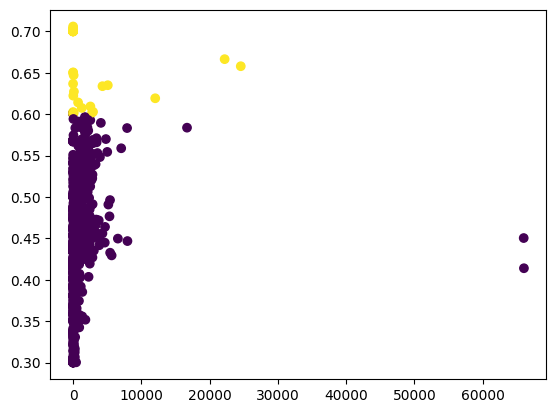

In [34]:
colors = operator_stats['score'] > operator_stats['score'].quantile(0.95)

plt.scatter(
    operator_stats['calls_count'],
    operator_stats['score'],
    c=colors
)

plt.show()

In [35]:
operator_stats.sort_values(by='score', ascending=False).head(50)

,operator_id,calls_count,missed_rate,call_duration,wait_time,outgoing_calls,score
324,909308.0,15,1.000000,0.000000,116.333333,15.0,0.705841
617,932246.0,1,1.000000,0.000000,60.000000,1.0,0.703044
1041,962904.0,2,1.000000,0.000000,43.000000,2.0,0.702176
697,937770.0,1,1.000000,0.000000,37.000000,1.0,0.701876
666,936296.0,4,1.000000,0.000000,34.666667,4.0,0.701744
841,945074.0,3,1.000000,0.000000,26.000000,3.0,0.701308
160,899076.0,2,1.000000,0.000000,23.500000,2.0,0.701186
92,891976.0,2,1.000000,0.000000,23.000000,2.0,0.701161
688,937716.0,1,1.000000,0.000000,19.000000,1.0,0.700962
700,937778.0,1,1.000000,0.000000,19.000000,1.0,0.700962


## Pruebas de hipótesis

### Comparar operadores eficientes vs ineficientes

Hipótesis:
- H0 (nula):
No hay diferencia en el tiempo de espera entre operadores eficientes e ineficientes
- H1 (alternativa):
Los operadores ineficientes tienen mayor tiempo de espera

In [42]:
# Definir ineficientes (top 5%)
threshold = operator_stats['score'].quantile(0.95)

# Separar grupos
inefficient = operator_stats[operator_stats['score'] >= threshold]['wait_time']
efficient = operator_stats[operator_stats['score'] < threshold]['wait_time']

# Prueba t
t_stat, p_value = stats.ttest_ind(inefficient, efficient, equal_var=False)

print("p-value:", p_value)

p-value: 0.03450735479814509


In [43]:
if p_value < 0.05:
    print("Rechazamos H0")
    print("Existe diferencia significativa")
    print("Los operadores ineficientes tienen mayor tiempo de espera")
else:
    print("No hay evidencia suficiente para rechazar H0")

Rechazamos H0
Existe diferencia significativa
Los operadores ineficientes tienen mayor tiempo de espera


## Hipótesis 2

### Relación entre llamadas perdidas y tiempo de espera
Hipótesis:
- H0: No hay relación entre missed_rate y wait_time
- H1: Sí hay relación

In [44]:
corr, p_value = stats.pearsonr(
    operator_stats['missed_rate'], operator_stats['wait_time'])

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.23698748227551483
p-value: 2.093170839392635e-15


In [45]:
if p_value < 0.05:
    print("Existe una relación estadísticamente significativa")

    if corr > 0:
        print(
            "Mientras mayor es el tiempo de espera, mayor es el número de llamadas perdidas")

    print("Esto respalda el modelo de ineficiencia")
else:
    print("No se encontró una relación estadísticamente significativa")

Existe una relación estadísticamente significativa
Mientras mayor es el tiempo de espera, mayor es el número de llamadas perdidas
Esto respalda el modelo de ineficiencia


## Hipótesis 3

### Llamadas realizadas vs eficiencia

- H0: El número de llamadas no afecta la eficiencia.
- H1: Menos llamadas = más ineficiencia.

In [47]:
# Nivel de significancia
alpha = 0.05

# Test estadístico
t_stat, p_value = stats.ttest_ind(
    inefficient_calls, efficient_calls, equal_var=False)

print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}\n")

# Decisión
if p_value < alpha:
    print("Rechazamos H0")
    print("Existe diferencia estadísticamente significativa en el número de llamadas")

    # Interpretación adicional según medias
    if inefficient_calls.mean() < efficient_calls.mean():
        print("Los operadores ineficientes realizan menos llamadas")
        print("Esto respalda la hipótesis de que menos llamadas = más ineficiencia")
    else:
        print(
            "Resultado inesperado: los operadores ineficientes no realizan menos llamadas")
else:
    print("No hay evidencia suficiente para rechazar H0")

t-statistic: 1.1965300329984039
p-value: 0.2364891408306591

No hay evidencia suficiente para rechazar H0


# Conclusiones

